In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# No cambien el nombre del csv, cuenta duplicados
RUTA = "toneladas_carga_SFM_2510.csv"
df = pd.read_csv(RUTA)

print("Filas, columnas:", df.shape)
df.head()

Filas, columnas: (384994, 7)


,per_anual,per_mes,grupo,subgrupo,producto,ton_netas,fecha
0,2014,Enero,Agrícolas,Forrajes,Cáscara de soya,1915.142,2014-01-01
1,2014,Enero,Agrícolas,Forrajes,Cáscara de soya,308.250,2014-01-01
2,2014,Enero,Agrícolas,Forrajes,Forrajes pastas y semillas oleaginosas,33582.135,2014-01-01
3,2014,Enero,Agrícolas,Forrajes,Forrajes pastas y semillas oleaginosas,81.950,2014-01-01
4,2014,Enero,Agrícolas,Forrajes,Forrajes pastas y semillas oleaginosas,784.601,2014-01-01


In [2]:
display(df.info())

print("\nColumnas:")
print(list(df.columns))

df.dtypes

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 384994 entries, 0 to 384993
Data columns (total 7 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   per_anual  384994 non-null  int64  
 1   per_mes    384994 non-null  object 
 2   grupo      384994 non-null  object 
 3   subgrupo   384994 non-null  object 
 4   producto   384994 non-null  object 
 5   ton_netas  384841 non-null  float64
 6   fecha      384994 non-null  object 
dtypes: float64(1), int64(1), object(5)
memory usage: 20.6+ MB


None


Columnas:
['per_anual', 'per_mes', 'grupo', 'subgrupo', 'producto', 'ton_netas', 'fecha']


per_anual      int64
per_mes       object
grupo         object
subgrupo      object
producto      object
ton_netas    float64
fecha         object
dtype: object

In [3]:
df2 = df.copy()

# De otra forma cree que es cadena
df2['fecha'] = pd.to_datetime(df2['fecha'], errors='coerce')

df2['ton_netas'] = pd.to_numeric(df2['ton_netas'], errors='coerce')

# nulos
print("Nulos en fecha:", df2['fecha'].isna().sum())
print("Nulos en ton_netas:", df2['ton_netas'].isna().sum())

df2.head()

Nulos en fecha: 0
Nulos en ton_netas: 153


,per_anual,per_mes,grupo,subgrupo,producto,ton_netas,fecha
0,2014,Enero,Agrícolas,Forrajes,Cáscara de soya,1915.142,2014-01-01
1,2014,Enero,Agrícolas,Forrajes,Cáscara de soya,308.250,2014-01-01
2,2014,Enero,Agrícolas,Forrajes,Forrajes pastas y semillas oleaginosas,33582.135,2014-01-01
3,2014,Enero,Agrícolas,Forrajes,Forrajes pastas y semillas oleaginosas,81.950,2014-01-01
4,2014,Enero,Agrícolas,Forrajes,Forrajes pastas y semillas oleaginosas,784.601,2014-01-01


In [4]:
nulos = df2.isna().sum().sort_values(ascending=True)

print("Nulos por columna:")
display(nulos)

dup = df2.duplicated().sum()
print("\nFilas duplicadas exactas:", dup)

Nulos por columna:


per_anual      0
per_mes        0
grupo          0
subgrupo       0
producto       0
fecha          0
ton_netas    153
dtype: int64


Filas duplicadas exactas: 32577


In [5]:
fmin, fmax = df2['fecha'].min(), df2['fecha'].max()
print("Rango de fechas:", fmin, "→", fmax)

# año
df2['año'] = df2['fecha'].dt.year
conteo_anual = df2.groupby('año').size().sort_index()

print("\nNúmero de años en el dataset:", conteo_anual.shape[0])
print("Registros por año:")

display(conteo_anual)

Rango de fechas: 2014-01-01 00:00:00 → 2025-10-01 00:00:00

Número de años en el dataset: 12
Registros por año:


año
2014      8874
2015      8663
2016      8337
2017      8991
2018     25854
2019     20259
2020     16529
2021     21458
2022     24190
2023     23057
2024    118306
2025    100476
dtype: int64

In [6]:
df2['ton_netas'].describe()

count    384841.000000
mean       3862.316212
std       18535.167304
min       -1704.560000
25%          85.479000
50%         217.199000
75%        1286.640000
max      693085.244000
Name: ton_netas, dtype: float64

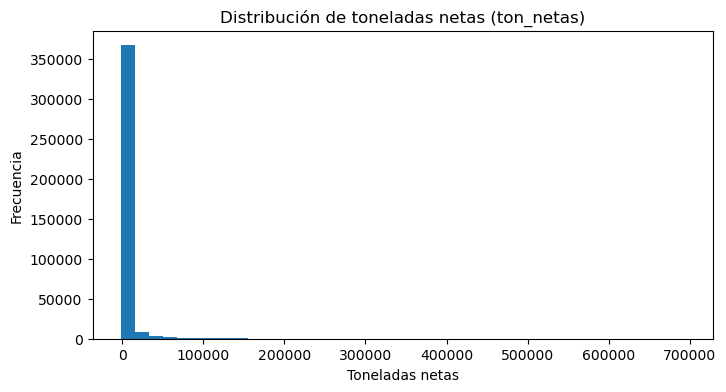

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.hist(df2['ton_netas'], bins=40)
plt.title("Distribución de toneladas netas (ton_netas)")
plt.xlabel("Toneladas netas")
plt.ylabel("Frecuencia")
plt.show()

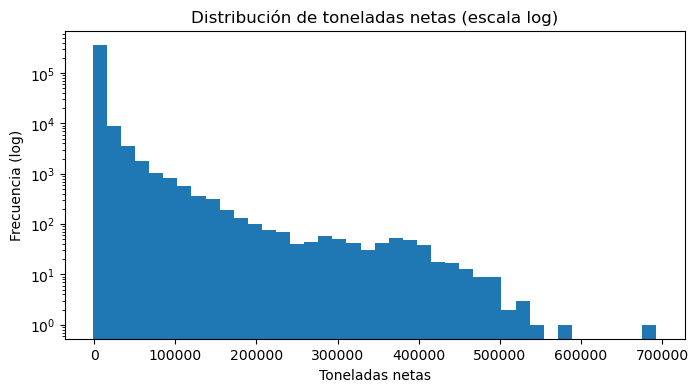

In [8]:
plt.figure(figsize=(8,4))
plt.hist(df2['ton_netas'], bins=40, log=True)
plt.title("Distribución de toneladas netas (escala log)")
plt.xlabel("Toneladas netas")
plt.ylabel("Frecuencia (log)")
plt.show()

In [9]:
dfp = df2.copy()

print("Dimensiones:", dfp.shape)
print("Nulos ton_netas:", dfp['ton_netas'].isna().sum())
print("Negativos ton_netas:", (dfp['ton_netas'] < 0).sum())
print("Duplicados exactos:", dfp.duplicated().sum())

Dimensiones: (384994, 8)
Nulos ton_netas: 153
Negativos ton_netas: 8
Duplicados exactos: 32577


In [10]:
list(df2.columns)

['per_anual',
 'per_mes',
 'grupo',
 'subgrupo',
 'producto',
 'ton_netas',
 'fecha',
 'año']

In [11]:
antes = dfp.shape[0]
dfp = dfp.drop_duplicates()
despues = dfp.shape[0]

print("Filas eliminadas por duplicado exacto:", antes - despues)
print("Datos después de limpieza:", dfp.shape)
print("Nulos ton_netas:", dfp['ton_netas'].isna().sum())
print("Negativos ton_netas:", (dfp['ton_netas'] < 0).sum())

Filas eliminadas por duplicado exacto: 32577
Datos después de limpieza: (352417, 8)
Nulos ton_netas: 137
Negativos ton_netas: 8


In [12]:
antes = dfp.shape[0]
dfp = dfp[dfp['ton_netas'].isna() | (dfp['ton_netas'] >= 0)].copy()
despues = dfp.shape[0]

print("Filas eliminadas por ton_netas negativa:", antes - despues)
print("Negativos restantes:", (dfp['ton_netas'] < 0).sum())

Filas eliminadas por ton_netas negativa: 8
Negativos restantes: 0


In [13]:
import pandas as pd
import numpy as np

df_imp = dfp.copy()

# ya no vi si se convirtieron
df_imp['fecha'] = pd.to_datetime(df_imp['fecha'], errors='coerce')
df_imp['ton_netas'] = pd.to_numeric(df_imp['ton_netas'], errors='coerce')

df_imp = df_imp.drop_duplicates()

df_imp = df_imp[df_imp['ton_netas'].isna() | (df_imp['ton_netas'] >= 0)].copy()

ts_m = (
    df_imp.dropna(subset=['fecha'])
          .set_index('fecha')['ton_netas']
          .resample('MS')
          .sum(min_count=1)   
          .sort_index()
)

print("Rango fechas:", ts_m.index.min(), "→", ts_m.index.max())
print("Meses en serie (observados):", ts_m.shape[0])
print("Meses con NaN (antes):", int(ts_m.isna().sum()))

idx = pd.date_range(ts_m.index.min(), ts_m.index.max(), freq='MS')
ts_m = ts_m.reindex(idx)

print("Meses en serie (continuo):", ts_m.shape[0])
print("Meses con NaN (continuo, antes):", int(ts_m.isna().sum()))

ts_m_imp = ts_m.interpolate(method='time')
ts_m_imp = ts_m_imp.ffill().bfill()

print("Meses con NaN (después):", int(ts_m_imp.isna().sum()))

ts_m_imp.head(12)

Rango fechas: 2014-01-01 00:00:00 → 2025-10-01 00:00:00
Meses en serie (observados): 142
Meses con NaN (antes): 0
Meses en serie (continuo): 142
Meses con NaN (continuo, antes): 0
Meses con NaN (después): 0


2014-01-01    9.285741e+06
2014-02-01    8.566469e+06
2014-03-01    9.788594e+06
2014-04-01    9.694448e+06
2014-05-01    1.020123e+07
2014-06-01    9.790476e+06
2014-07-01    1.027698e+07
2014-08-01    9.909119e+06
2014-09-01    9.434184e+06
2014-10-01    9.721202e+06
2014-11-01    9.321755e+06
2014-12-01    9.506122e+06
Freq: MS, Name: ton_netas, dtype: float64

In [31]:
mes_map = {
    "Enero": 1,
    "Febrero": 2,
    "Marzo": 3,
    "Abril": 4,
    "Mayo": 5,
    "Junio": 6,
    "Julio": 7,
    "Agosto": 8,
    "Septiembre": 9,
    "Octubre": 10,
    "Noviembre": 11,
    "Diciembre": 12
}

dfp["mes_num"] = dfp["per_mes"].map(mes_map)

dfp["anio_mes"] = pd.to_datetime(
    dict(
        year=dfp["per_anual"],
        month=dfp["mes_num"],
        day=1
    )
)

In [32]:
print("Nulos ANTES en ton_netas:", dfp['ton_netas'].isna().sum())

# Mediana mensual
mediana_mensual = dfp.groupby('anio_mes')['ton_netas'].transform('median')

# Imputación
dfp['ton_netas'] = dfp['ton_netas'].fillna(mediana_mensual)

# Nulos después
print("Nulos DESPUÉS en ton_netas:", dfp['ton_netas'].isna().sum())

Nulos ANTES en ton_netas: 137
Nulos DESPUÉS en ton_netas: 0


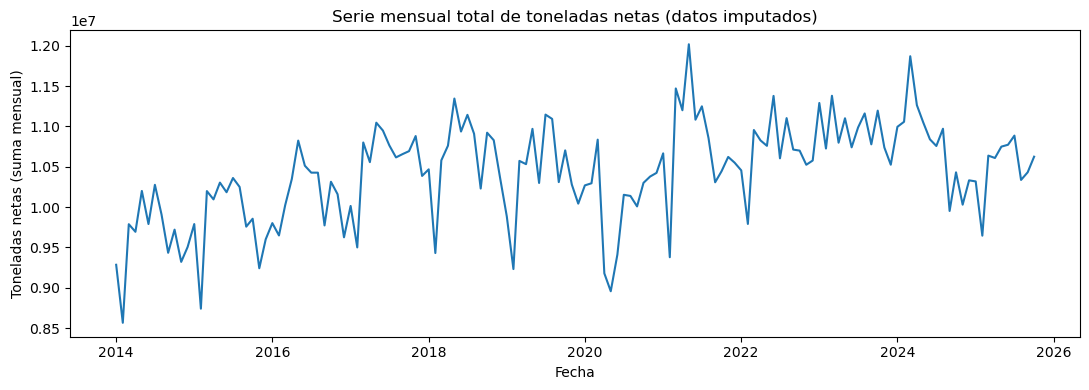

In [15]:
ts_m = (
    dfp.set_index('fecha')['ton_netas']
       .resample('MS')
       .sum()
       .sort_index()
)

plt.figure(figsize=(11,4))
plt.plot(ts_m.index, ts_m.values)

plt.title("Serie mensual total de toneladas netas (datos imputados)")
plt.xlabel("Fecha")
plt.ylabel("Toneladas netas (suma mensual)")

plt.tight_layout()
plt.show()

### Medias móviles y aparición de valores NaN

Los valores **NaN** que aparecen al inicio de las columnas `ma_3`, `ma_6` y `ma_12` se deben al funcionamiento de las **ventanas móviles (`rolling`)**.

Una media móvil necesita un número mínimo de observaciones para poder calcularse:

- `ma_3` necesita **3 meses** de datos
- `ma_6` necesita **6 meses** de datos
- `ma_12` necesita **12 meses** de datos

Por esta razón, en los primeros registros del dataset no existe suficiente información histórica para calcular la media, por lo que **Pandas asigna NaN automáticamente** hasta que se completa el tamaño de la ventana.

Este comportamiento es esperado y forma parte del cálculo normal de las medias móviles en series de tiempo.

In [16]:

df_ma = ts_m.to_frame(name='ton_netas')

df_ma['ma_3'] = df_ma['ton_netas'].rolling(3).mean()
df_ma['ma_6'] = df_ma['ton_netas'].rolling(6).mean()
df_ma['ma_12'] = df_ma['ton_netas'].rolling(12).mean()

df_ma.head(15)

,ton_netas,ma_3,ma_6,ma_12
fecha,,,,
2014-01-01,9.285741e+06,NaN,NaN,NaN
2014-02-01,8.566469e+06,NaN,NaN,NaN
2014-03-01,9.788594e+06,9.213601e+06,NaN,NaN
2014-04-01,9.694448e+06,9.349837e+06,NaN,NaN
2014-05-01,1.020123e+07,9.894757e+06,NaN,NaN
2014-06-01,9.790476e+06,9.895384e+06,9.554493e+06,NaN
2014-07-01,1.027698e+07,1.008956e+07,9.719699e+06,NaN
2014-08-01,9.909119e+06,9.992191e+06,9.943474e+06,NaN
2014-09-01,9.434184e+06,9.873427e+06,9.884406e+06,NaN


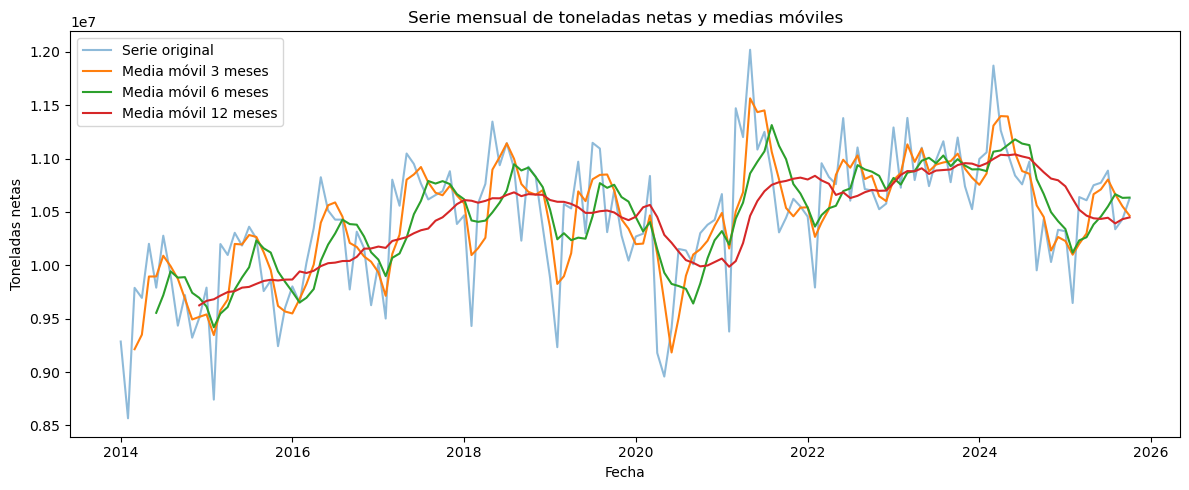

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(df_ma.index, df_ma['ton_netas'], label='Serie original', alpha=0.5)
plt.plot(df_ma.index, df_ma['ma_3'], label='Media móvil 3 meses')
plt.plot(df_ma.index, df_ma['ma_6'], label='Media móvil 6 meses')
plt.plot(df_ma.index, df_ma['ma_12'], label='Media móvil 12 meses')

plt.title("Serie mensual de toneladas netas y medias móviles")
plt.xlabel("Fecha")
plt.ylabel("Toneladas netas")

plt.legend()
plt.tight_layout()
plt.show()# se acorta al inicio por el calculo de la media movil

In [18]:

df_features = ts_m.to_frame(name='ton_netas')

# demanda del mismo mes del año anterior
df_features['lag_12'] = df_features['ton_netas'].shift(12)

# crecimiento anual de la demanda
df_features['crecimiento_anual'] = (
    (df_features['ton_netas'] - df_features['lag_12']) / df_features['lag_12']
)

df_features.head()

,ton_netas,lag_12,crecimiento_anual
fecha,,,
2014-01-01,9.285741e+06,NaN,NaN
2014-02-01,8.566469e+06,NaN,NaN
2014-03-01,9.788594e+06,NaN,NaN
2014-04-01,9.694448e+06,NaN,NaN
2014-05-01,1.020123e+07,NaN,NaN


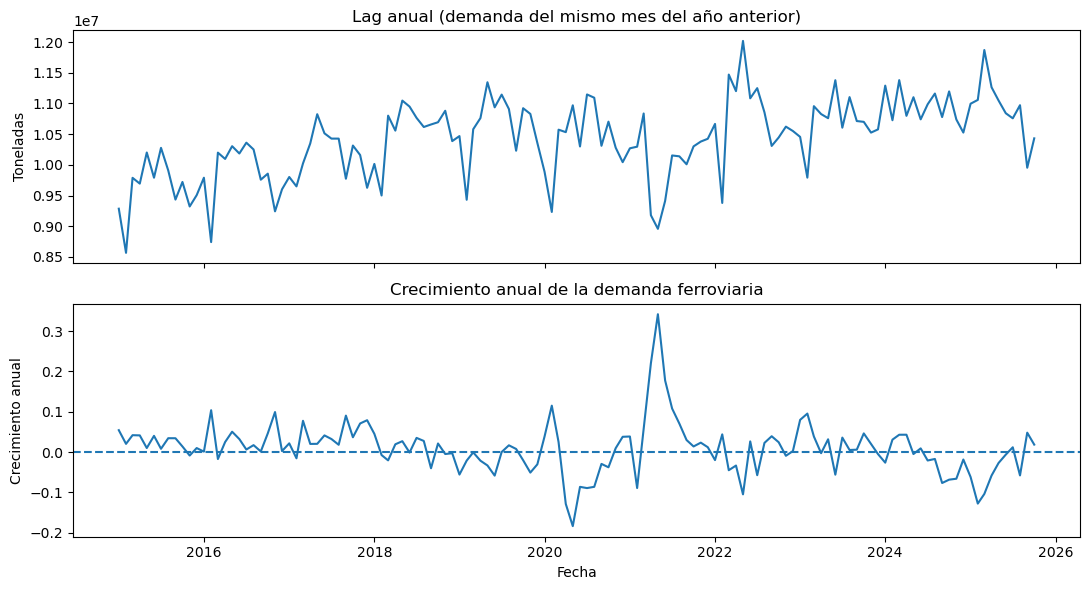

In [19]:
fig, ax = plt.subplots(2, 1, figsize=(11,6), sharex=True)

ax[0].plot(df_features.index, df_features['lag_12'])
ax[0].set_title("Lag anual (demanda del mismo mes del año anterior)")
ax[0].set_ylabel("Toneladas")

ax[1].plot(df_features.index, df_features['crecimiento_anual'])
ax[1].axhline(0, linestyle='--')
ax[1].set_title("Crecimiento anual de la demanda ferroviaria")
ax[1].set_ylabel("Crecimiento anual")
ax[1].set_xlabel("Fecha")

plt.tight_layout()
plt.show()

Antes


,ton_netas,lag_12,crecimiento_anual
count,1.420000e+02,1.300000e+02,130.000000
mean,1.042437e+07,1.042214e+07,0.009546
std,6.111117e+05,6.306576e+05,0.062900
min,8.566469e+06,8.566469e+06,-0.183506
25%,1.005681e+07,1.002867e+07,-0.020390
50%,1.049116e+07,1.049116e+07,0.012044
75%,1.082924e+07,1.083987e+07,0.037669
max,1.201917e+07,1.201917e+07,0.341813


Después


,ton_netas,lag_12,crecimiento_anual
count,1.420000e+02,1.300000e+02,1.300000e+02
mean,8.756689e-16,1.694371e-15,1.366428e-17
std,1.003540e+00,1.003868e+00,1.003868e+00
min,-3.050957e+00,-2.953817e+00,-3.081087e+00
25%,-6.035828e-01,-6.263151e-01,-4.777722e-01
50%,1.096830e-01,1.098682e-01,3.985682e-02
75%,6.648595e-01,6.649297e-01,4.488306e-01
max,2.618915e+00,2.542128e+00,5.302927e+00


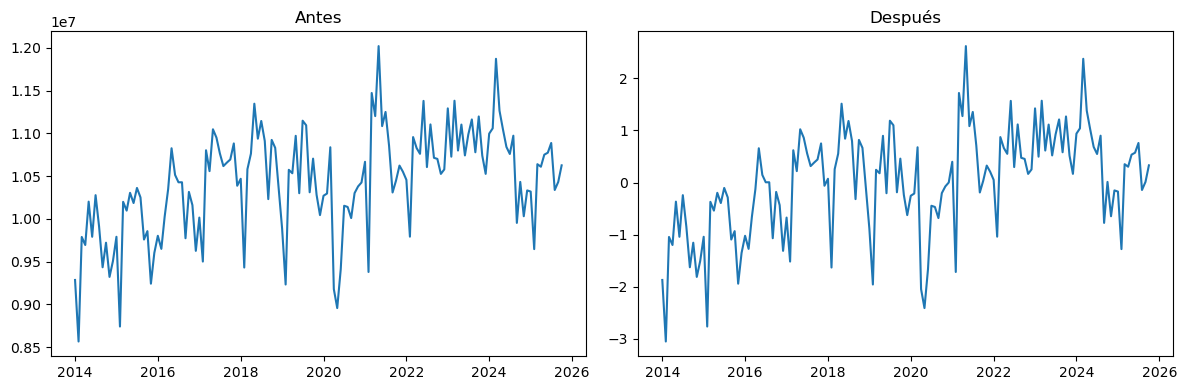

In [20]:
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

cols = ['ton_netas', 'lag_12', 'crecimiento_anual']

# antes del escalado
print("Antes")
display(df_features[cols].describe())

# después del escalado
scaler = StandardScaler()
df_scaled = df_features.copy()
df_scaled[cols] = scaler.fit_transform(df_scaled[cols])

print("Después")
display(df_scaled[cols].describe())

# visualización 
fig, ax = plt.subplots(1, 2, figsize=(12,4))

ax[0].plot(df_features.index, df_features['ton_netas'])
ax[0].set_title("Antes")

ax[1].plot(df_scaled.index, df_scaled['ton_netas'])
ax[1].set_title("Después")

plt.tight_layout()
plt.show()

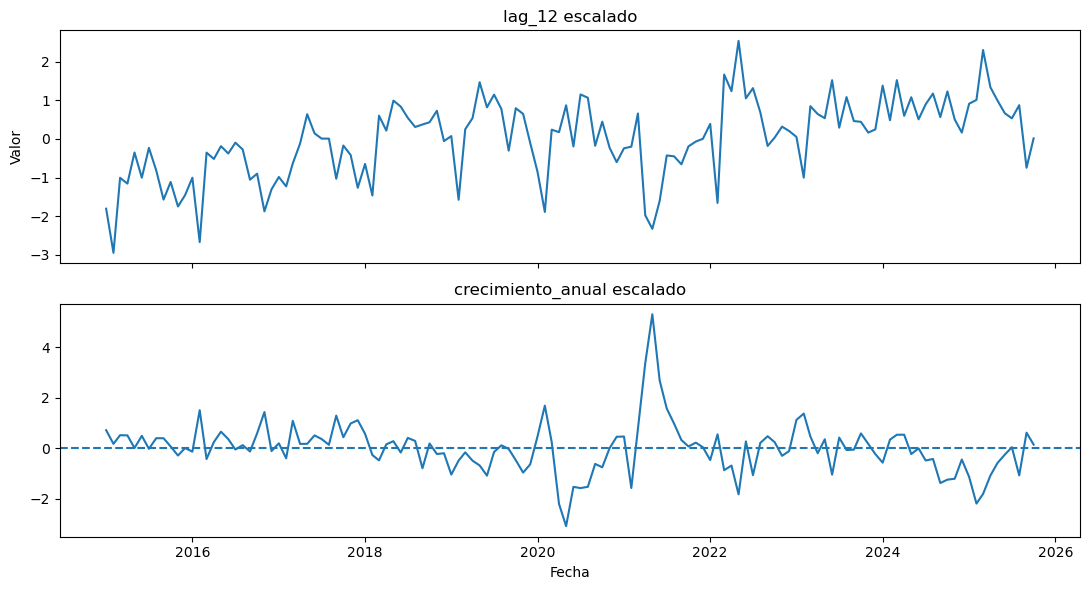

In [21]:
fig, ax = plt.subplots(2, 1, figsize=(11,6), sharex=True)

ax[0].plot(df_scaled.index, df_scaled['lag_12'])
ax[0].set_title("lag_12 escalado")
ax[0].set_ylabel("Valor")

ax[1].plot(df_scaled.index, df_scaled['crecimiento_anual'])
ax[1].axhline(0, linestyle='--')
ax[1].set_title("crecimiento_anual escalado")
ax[1].set_xlabel("Fecha")

plt.tight_layout()
plt.show()

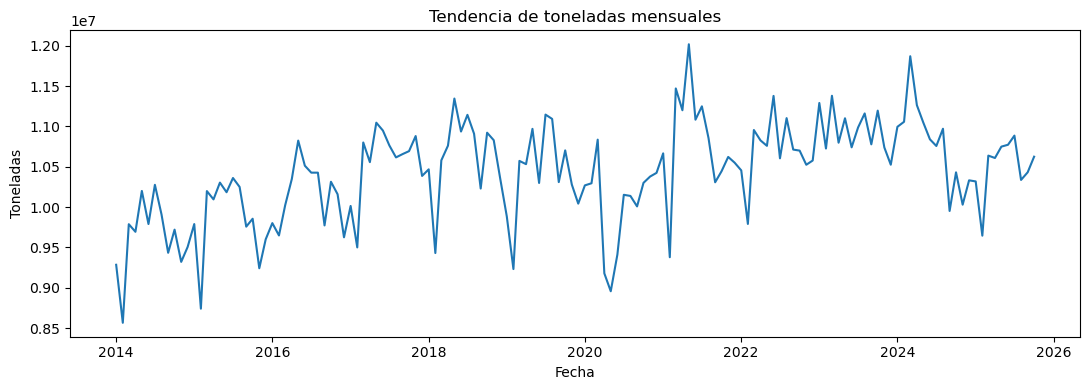

In [22]:
plt.figure(figsize=(11,4))

plt.plot(ts_m.index, ts_m.values)

plt.title("Tendencia de toneladas mensuales")
plt.xlabel("Fecha")
plt.ylabel("Toneladas")

plt.tight_layout()
plt.show()

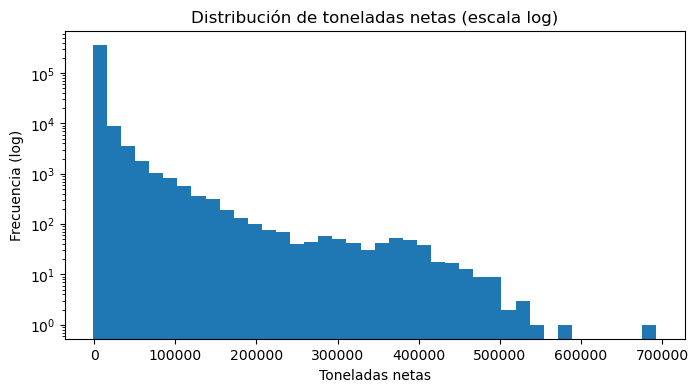

In [23]:
# de nuevo a escala log porque no se aprecia bien la distribución
plt.figure(figsize=(8,4))
plt.hist(df2['ton_netas'], bins=40, log=True)
plt.title("Distribución de toneladas netas (escala log)")
plt.xlabel("Toneladas netas")
plt.ylabel("Frecuencia (log)")
plt.show()

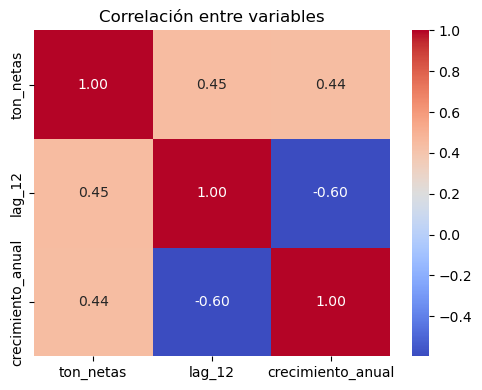

In [24]:
import seaborn as sns

corr = df_features[['ton_netas','lag_12','crecimiento_anual']].corr()

plt.figure(figsize=(5,4))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlación entre variables")

plt.tight_layout()
plt.show()

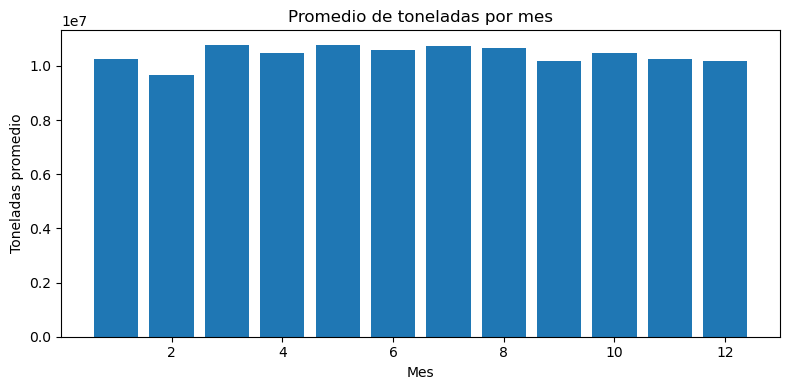

In [25]:
df_mes = ts_m.to_frame(name='ton_netas')
df_mes['mes'] = df_mes.index.month

prom_mes = df_mes.groupby('mes')['ton_netas'].mean()

plt.figure(figsize=(8,4))
plt.bar(prom_mes.index, prom_mes.values)

plt.title("Promedio de toneladas por mes")
plt.xlabel("Mes")
plt.ylabel("Toneladas promedio")

plt.tight_layout()
plt.show()

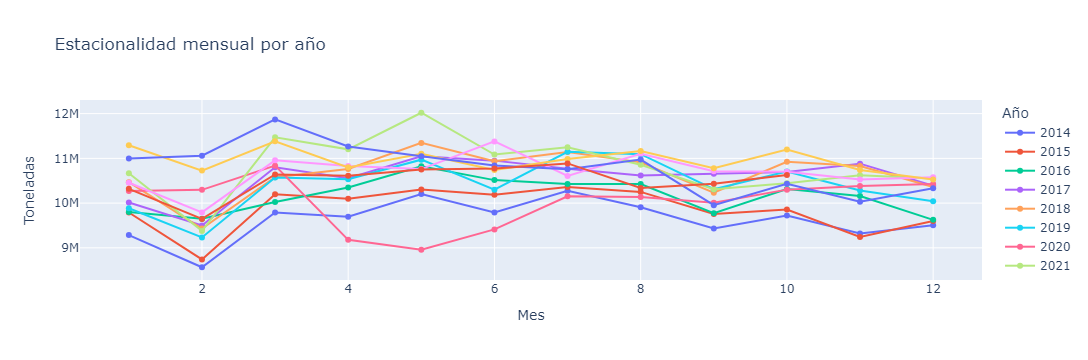

In [26]:

import plotly.express as px # lo cabie a potly para que puedan verse mejor los datos, y se vean mejores las graficas

df_season = ts_m.to_frame(name='ton_netas')

df_season['anio'] = df_season.index.year
df_season['mes'] = df_season.index.month

fig = px.line(
    df_season,
    x='mes',
    y='ton_netas',
    color='anio',
    markers=True,
    title="Estacionalidad mensual por año",
    labels={'mes':'Mes','ton_netas':'Toneladas','anio':'Año'}
)

fig.show()

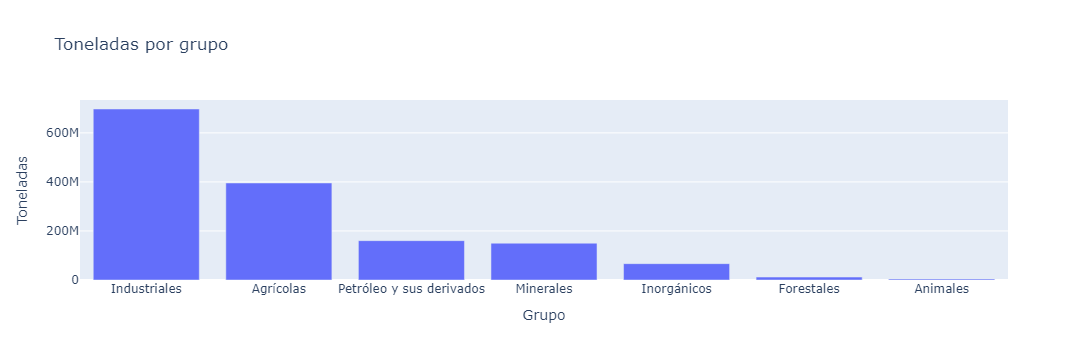

In [27]:
import plotly.express as px

top_grupos = (
    df2.groupby('grupo')['ton_netas']
    .sum()
    .sort_values(ascending=False)
    .head(7)
    .reset_index()
)

fig = px.bar(
    top_grupos,
    x='grupo',
    y='ton_netas',
    title="Toneladas por grupo",
    labels={'grupo': 'Grupo', 'ton_netas': 'Toneladas'}
)

fig.show()

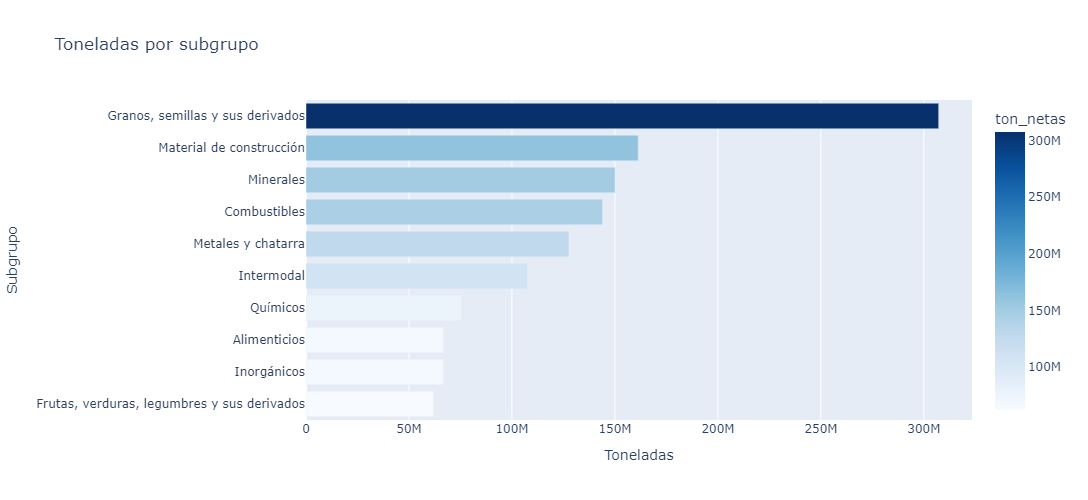

In [28]:
import plotly.express as px
#las ouse por subgrupos, para ver otro enfoque y sea mas exacto su distribucion
top_sub = (
    df2.groupby('subgrupo')['ton_netas']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

fig = px.bar(
    top_sub,
    x='ton_netas',
    y='subgrupo',
    orientation='h',
    color='ton_netas',
    color_continuous_scale='Blues',
    title="Toneladas por subgrupo"
)

fig.update_layout(
    yaxis={'categoryorder':'total ascending'},
    xaxis_title="Toneladas",
    yaxis_title="Subgrupo",
    height=500
)

fig.show()

C:\Users\migue\AppData\Local\Temp\ipykernel_21036\640684852.py:1: FutureWarning:

'Y' is deprecated and will be removed in a future version, please use 'YE' instead.



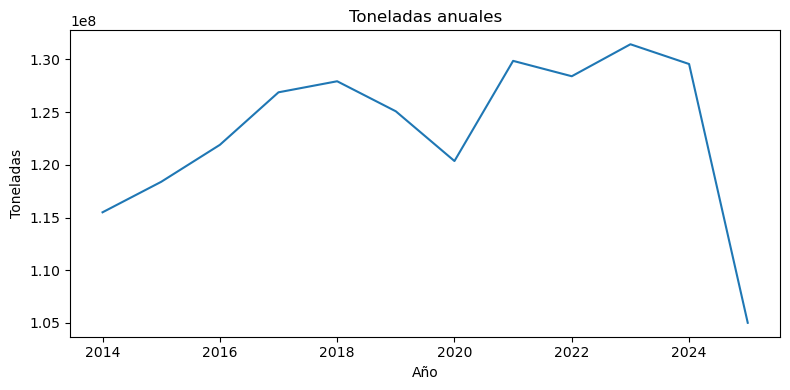

In [29]:
df_anual = ts_m.resample('Y').sum() # debemos modificar para que no salga la advertencia

plt.figure(figsize=(8,4))

plt.plot(df_anual.index.year, df_anual.values)

plt.title("Toneladas anuales")
plt.xlabel("Año")
plt.ylabel("Toneladas")

plt.tight_layout()
plt.show()